In [1]:
from abc import abstractmethod
%load_ext autoreload
%autoreload 2

%aimport -torch
%aimport -numpy
%aimport -qiskit
%aimport -pennylane

from pathlib import Path

from qiskit.transpiler.passes.analysis import num_qubits

# These import from Data folder are necessary for pickle load to work
from Data.synthetic_dataset_generator import DataRequest
from Data.environment_classes import Drone, Radar, Context
from Data.noise_models import AdditiveWhiteGaussianNoise
from Data.synthetic_dataset_generator import DatasetMetadata

from MachineLearning.Preprocessing.file_loader import SyntheticDataFileLoader
from MachineLearning.Preprocessing.frequency_domain_parser import FrequencyDomainDataParser
from MachineLearning.Preprocessing.time_domain_parser import TimeDomainDataParser
from MachineLearning.Torch_datasets.synthetic_time_dataset import SyntheticTimeDomainRadarDataset
from MachineLearning.Torch_datasets.synthethic_frequency_dataset import SyntheticFrequencyDomainRadarDataset

from MachineLearning.Models.experiment_pure.classical_neural_network import ClassicalNeuralNetwork
from MachineLearning.Models.experiment_pure.quantum_neural_network import QuantumNeuralNetwork

from matplotlib import pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
import pennylane as qml

## Checking preprocessing functionalities

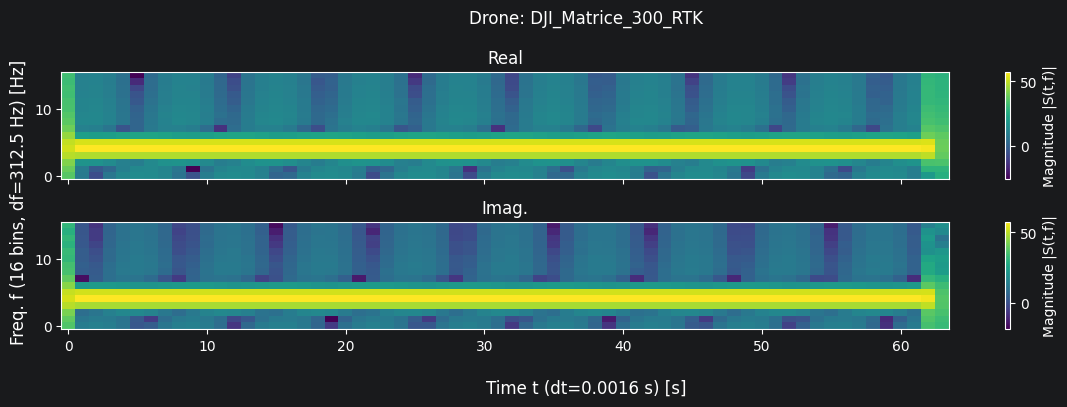

In [9]:
PROJECT_ROOT = Path().cwd().parent
type = "time_domain"
load_path = PROJECT_ROOT / "Data" / "Datasets" / type / "training_dataset.pkl"

md = DatasetMetadata.create_from_path(load_path)
synt_dataset = SyntheticDataFileLoader(dataset_metadata=md)

obj = synt_dataset.peek_sample(index=6000)

td_data_parser = TimeDomainDataParser()
signal, label, misc_data = td_data_parser.extract_training_data_and_label(obj)
td_data_parser.plot_drone_spectrogram(signal, misc_data, nperseg=32, noverlap=16)

In [10]:
parsed_signal, label, misc_data = td_data_parser.parse_data_object(obj)
parsed_signal, label, misc_data

(tensor([ 7.0232,  3.6288,  2.5064,  2.2650,  1.9713,  2.2520,  2.4046,  3.3200,
          6.2894, 89.2546]),
 1,
 DataRequest(request_name='label=DJI_Matrice_300_RTK', drone=Drone(name='DJI_Matrice_300_RTK', N=2, L_1=0.05, L_2=0.2665, f_rot=70), radar=Radar(λ=0.02998, f_c=9999748432.288193), context=Context(R=1520.0568606927932, V_rad=29.999718426099054, θ=0.3926806281264518, Φ_p=0.6228512920884408, A_r=7.299403777764336, snr=np.int64(25), t_start=0, t_stop=0.1, dt=0.0001), noise_model=<Data.noise_models.AdditiveWhiteGaussianNoise object at 0x000001B200591040>, sample_size=70))

In [11]:
PROJECT_ROOT = Path().cwd().parent
type = "frequency_domain"
load_path = PROJECT_ROOT / "Data" / "Datasets" / type / "training_dataset.pkl"

md = DatasetMetadata.create_from_path(load_path)
synt_dataset = SyntheticDataFileLoader(dataset_metadata=md)

obj = synt_dataset.peek_sample(index=6000)

td_data_parser = FrequencyDomainDataParser()
signal, label, misc_data = td_data_parser.parse_data_object(obj, bin_size=1, return_mag=False)
print(signal.shape)

torch.Size([2, 16, 64])


## Training pipeline

In [8]:
from abc import ABC, abstractmethod

class AbstractTrainer(ABC):
    def __init__(self, model, training_dataloader, validating_dataloader, testing_dataloader, loss_fn, optimizer, device):
        self.training_dataloader = training_dataloader
        self.validating_dataloader = validating_dataloader
        self.testing_dataloader = testing_dataloader
        self.model = model
        self.loss_fn = loss_fn
        self.optimizer = optimizer
        self.device = device

    @abstractmethod
    def train(self):
        pass

    @abstractmethod
    def test(self):
        pass

class BasicTrainer(AbstractTrainer):
    def __init__(self, model, training_dataloader, validating_dataloader, testing_dataloader, loss_fn, optimizer, device='cpu'):
        super().__init__(model, training_dataloader, validating_dataloader, testing_dataloader, loss_fn, optimizer, device)

    def train(self):
        size = len(self.training_dataloader.dataset)
        self.model.train()
        for batch, (X, y) in enumerate(self.training_dataloader):
            X, y = X.to(self.device), y.to(self.device)

            pred = self.model(X)
            loss = self.loss_fn(pred, y)

            loss.backward()
            self.optimizer.step()
            self.optimizer.zero_grad()

            if batch % 100 == 0:
                loss, current = loss.item(), (batch + 1) * len(X)
                print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

    def test(self):
        size = len(self.validating_dataloader.dataset)
        num_batches = len(validating_dataloader)
        self.model.eval()
        test_loss, correct = 0, 0
        with torch.no_grad():
            for X, y in self.validating_dataloader:
                X, y = X.to(device), y.to(device)
                pred = self.model(X)
                test_loss += self.loss_fn(pred, y).item()
                correct += (pred.argmax(1) == y).type(torch.float).sum().item()
        test_loss /= num_batches
        correct /= size
        print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
        return 100*correct

In [16]:
PROJECT_ROOT = Path().cwd().parent
type = "frequency_domain"
training_path = PROJECT_ROOT / "Data" / "Datasets" / type / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / type / "validating_dataset.pkl"

training_data = SyntheticFrequencyDomainRadarDataset(training_path)
validating_data = SyntheticFrequencyDomainRadarDataset(validating_path)

batch_size = 32
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
validating_dataloader = DataLoader(validating_data, batch_size=batch_size, shuffle=True)

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
model = ClassicalNeuralNetwork().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

trainer = BasicTrainer(
    model=model,
    training_dataloader=train_dataloader,
    validating_dataloader=validating_dataloader,
    testing_dataloader=None,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device
)

epochs = 20
accuracy_array=[]
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    trainer.train()
    acc = trainer.test()
    accuracy_array.append(acc)
print("Done!")

Epoch 1
-------------------------------
loss: 1.807897  [   32/ 8400]
loss: 1.362145  [ 3232/ 8400]
loss: 1.283617  [ 6432/ 8400]
Test Error: 
 Accuracy: 33.8%, Avg loss: 1.381886 

Epoch 2
-------------------------------
loss: 1.310247  [   32/ 8400]
loss: 1.418805  [ 3232/ 8400]
loss: 1.231183  [ 6432/ 8400]
Test Error: 
 Accuracy: 33.2%, Avg loss: 1.345104 

Epoch 3
-------------------------------
loss: 1.131550  [   32/ 8400]
loss: 1.389906  [ 3232/ 8400]
loss: 1.299570  [ 6432/ 8400]
Test Error: 
 Accuracy: 33.3%, Avg loss: 1.373290 

Epoch 4
-------------------------------
loss: 1.342370  [   32/ 8400]
loss: 1.243882  [ 3232/ 8400]
loss: 1.359397  [ 6432/ 8400]
Test Error: 
 Accuracy: 34.1%, Avg loss: 1.337573 

Epoch 5
-------------------------------
loss: 1.303619  [   32/ 8400]
loss: 1.188062  [ 3232/ 8400]
loss: 1.399113  [ 6432/ 8400]
Test Error: 
 Accuracy: 34.4%, Avg loss: 1.340830 

Epoch 6
-------------------------------
loss: 1.177310  [   32/ 8400]
loss: 1.147350  [ 32

In [23]:
accuracy_array

[33.791666666666664,
 33.25,
 33.33333333333333,
 34.08333333333333,
 34.375,
 36.291666666666664,
 33.958333333333336,
 35.583333333333336,
 35.70833333333333,
 35.75,
 36.70833333333333,
 36.75,
 36.833333333333336,
 37.458333333333336,
 35.95833333333333,
 35.75,
 36.41666666666667,
 37.79166666666667,
 37.458333333333336,
 37.458333333333336]

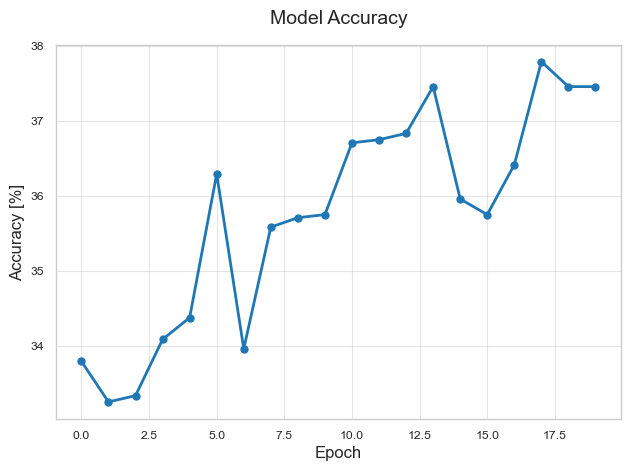

In [31]:
plt.plot(accuracy_array, marker='o', linestyle='-', color='#1f77b4', linewidth=2, markersize=5)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy", fontsize=14, pad=15)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy [%]", fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
type = "time_domain"
num_qubits = 10

PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / type / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / type / "validating_dataset.pkl"

training_data = SyntheticTimeDomainRadarDataset(training_path)
validating_data = SyntheticTimeDomainRadarDataset(validating_path)

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
validating_dataloader = DataLoader(validating_data, batch_size=64, shuffle=True)

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
quantum_model = QuantumNeuralNetwork(num_qubits).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(quantum_model.parameters(), lr=1e-3)

trainer = BasicTrainer(
    model=quantum_model,
    training_dataloader=train_dataloader,
    validating_dataloader=validating_dataloader,
    testing_dataloader=None,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device
)

epochs = 200
accuracy_array=[]
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    trainer.train()
    acc = trainer.test()
    accuracy_array.append(acc)
print("Done!")

Epoch 1
-------------------------------
loss: 1.778217  [   64/ 8400]


KeyboardInterrupt: 